In [5]:
from matplotlib import pyplot as plt
import matplotlib.gridspec as gridspec
import scipy
from scipy.stats import ttest_rel
from statsmodels.stats.multitest import multipletests
import os
import numpy as np
from scipy.stats import spearmanr
from scipy.ndimage import gaussian_filter
from sklearn.decomposition import PCA
from sklearn.preprocessing import RobustScaler
from mne.stats import spatio_temporal_cluster_test, f_mway_rm, f_threshold_mway_rm, permutation_cluster_1samp_test

def add_subplot_label(ax, label, x=-.21, y=1.225):
    ax.text(x, y, label,
            transform=ax.transAxes,
            fontsize=26, va='top', ha='right')

plt.rcParams.update({
        'font.size': 16,
        'axes.spines.right': False,
        'axes.spines.top': False,
        'xtick.major.size': 6,
        'xtick.major.width': 1.2,
        'ytick.major.size': 6,
        'ytick.major.width': 1.2,
        'legend.frameon': False,
        'legend.handletextpad': 0.1,
        'svg.fonttype': 'none',
        'text.usetex': False
    })

output_dir = '/home/qmoreau/schmidt_data/output'

bursts_all_results_laplac = np.load(f'{output_dir}/bursts_all_results_laplac.npy', allow_pickle=True)

#bursts_all_results_laplac = np.load(f'/home/common/bonaiuto/stop_go_bursts/derivatives/Dataset_1/bursts_all_results_laplac.npy', allow_pickle=True)

seen = set()
bursts_deduped = []
for b in bursts_all_results_laplac:
    if len(b['condition']) == 0:
        continue
    key = (b['subject'][0], b['condition'][0], b['electrode'][0])
    if key not in seen:
        seen.add(key)
        bursts_deduped.append(b)
bursts_all_results_laplac = bursts_deduped
print(f"After dedup: {len(bursts_all_results_laplac)} entries")

# Reinitialize as lists
all_bursts = {
    'trial': [], 'waveform': [], 'peak_freq': [], 'peak_amp_iter': [],
    'peak_amp_base': [], 'peak_time': [], 'peak_adjustment': [],
    'fwhm_freq': [], 'fwhm_time': [], 'polarity': [], 'waveform_times': [],
    'condition': [], 'electrode': [], 'subject': [], 'experiment': [], 'epochs': []
}

for bursts in bursts_all_results_laplac:
    for key in bursts:
        if key != 'waveform_times':
            all_bursts[key].extend(bursts[key])

for key in all_bursts:
    all_bursts[key] = np.array(all_bursts[key])

# Reconstruct waveform_times from waveform shape ? centered at 0
sfreq = 512
n_tp = all_bursts['waveform'].shape[1]  # 132
half_win = n_tp // 2
all_bursts['waveform_times'] = np.arange(-half_win, half_win + (n_tp % 2)) / sfreq

print(f"waveform_times reconstructed: {len(all_bursts['waveform_times'])} points")
print(f"  Range: {all_bursts['waveform_times'][0]*1e3:.1f} to {all_bursts['waveform_times'][-1]*1e3:.1f} ms")

# Remove baseline epochs
# bl_mask = ~np.isin(all_bursts['condition'], ['GO_bl', 'SS_bl', 'FS_bl'])
# for key in all_bursts:
#     if key != 'waveform_times':
#         all_bursts[key] = all_bursts[key][bl_mask]

# print(np.unique(all_bursts['condition']))

c3_idx = (all_bursts['electrode'] == 'C3')
f4_idx = (all_bursts['electrode'] == 'F4')

# Mean waveforms per subject
unique_subjects = np.unique(all_bursts['subject'])

mean_waveforms_laplac_C3 = []
for subject in unique_subjects:
    subject_waveforms = all_bursts['waveform'][c3_idx & (all_bursts['subject'] == subject)] * 1e3
    if len(subject_waveforms) > 0:
        mean_waveforms_laplac_C3.append(np.mean(subject_waveforms, axis=0))
matrix_mean_waveforms_laplac_C3 = np.array(mean_waveforms_laplac_C3)

mean_waveforms_laplac_F4 = []
for subject in unique_subjects:
    subject_waveforms = all_bursts['waveform'][f4_idx & (all_bursts['subject'] == subject)] * 1e3
    if len(subject_waveforms) > 0:
        mean_waveforms_laplac_F4.append(np.mean(subject_waveforms, axis=0))
matrix_mean_waveforms_laplac_F4 = np.array(mean_waveforms_laplac_F4)

# PCA
waveforms_laplac_C3 = all_bursts['waveform'][c3_idx, :]
model_laplac_C3 = PCA(n_components=20)
scaler_laplac_C3 = RobustScaler().fit(waveforms_laplac_C3)
waveforms_laplac_C3_std = scaler_laplac_C3.transform(waveforms_laplac_C3)
model_laplac_C3.fit(waveforms_laplac_C3_std)

waveforms_laplac_F4 = all_bursts['waveform'][f4_idx, :]
model_laplac_F4 = PCA(n_components=20)
scaler_laplac_F4 = RobustScaler().fit(waveforms_laplac_F4)
waveforms_laplac_F4_std = scaler_laplac_F4.transform(waveforms_laplac_F4)
model_laplac_F4.fit(waveforms_laplac_F4_std)


After dedup: 144 entries
waveform_times reconstructed: 132 points
  Range: -128.9 to 127.0 ms


PCA(n_components=20)

FileNotFoundError: [Errno 2] No such file or directory: '/home/qmoreau/schmidt_data/output/figures/figure_02_burst_features.pdf'

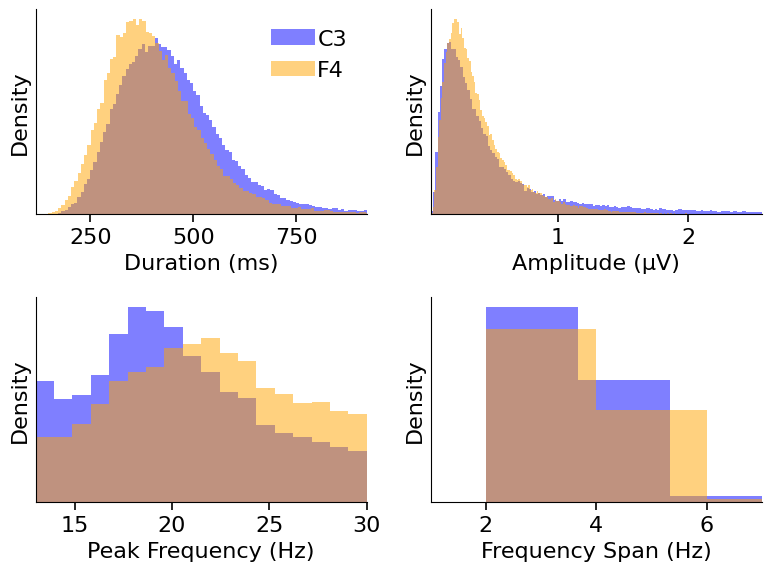

In [6]:
fig_a, axes_a = plt.subplots(2, 2, figsize=(8, 6))

ax = axes_a[0, 0]
ax.hist(all_bursts['fwhm_time'][c3_idx]*1e3, bins=380, alpha=0.5, color="blue", label="C3", density=True)
ax.hist(all_bursts['fwhm_time'][f4_idx]*1e3, bins=340, alpha=0.5, color="orange", label="F4", density=True)
ax.set_xlabel("Duration (ms)")
ax.set_xlim(np.percentile(all_bursts['fwhm_time']*1e3, [0, 99]))
ax.set_ylabel("Density")
ax.set_yticks([])
ax.legend()

ax = axes_a[0, 1]
ax.hist(all_bursts['peak_amp_base'][c3_idx]*1e3, bins=300, alpha=0.5, color="blue", label="C3", density=True)
ax.hist(all_bursts['peak_amp_base'][f4_idx]*1e3, bins=300, alpha=0.5, color="orange", label="F4", density=True)
ax.set_xlabel("Amplitude (µV)")
ax.set_xlim(np.percentile(all_bursts['peak_amp_base']*1e3, [0, 99]))
ax.set_ylabel("Density")
ax.set_yticks([])

ax = axes_a[1, 0]
ax.hist(all_bursts['peak_freq'][c3_idx], bins=18, alpha=0.5, color="blue", label="C3", density=True)
ax.hist(all_bursts['peak_freq'][f4_idx], bins=18, alpha=0.5, color="orange", label="F4", density=True)
ax.set_xlabel("Peak Frequency (Hz)")
ax.set_xlim(np.percentile(all_bursts['peak_freq'], [0, 100]))
ax.set_ylabel("Density")
ax.set_yticks([])

ax = axes_a[1, 1]
ax.hist(all_bursts['fwhm_freq'][c3_idx], bins=6, alpha=0.5, color="blue", label="C3", density=True)
ax.hist(all_bursts['fwhm_freq'][f4_idx], bins=6, alpha=0.5, color="orange", label="F4", density=True)
ax.set_xlim([1, 7])
ax.set_xlabel("Frequency Span (Hz)")
ax.set_ylabel("Density")
ax.set_yticks([])

plt.tight_layout()
plt.savefig(f'{output_dir}/figures/figure_02_burst_features.pdf', bbox_inches='tight')
plt.show()


In [ ]:
import pandas as pd
import statsmodels.formula.api as smf

# Build dataframe
df = pd.DataFrame({
    'duration':   all_bursts['fwhm_time'] * 1e3,        # ms
    'amplitude':  all_bursts['peak_amp_base'] * 1e3,    # µV
    'peak_freq':  all_bursts['peak_freq'],               # Hz
    'fwhm_freq':  all_bursts['fwhm_freq'],               # Hz
    'electrode':  np.where(c3_idx, 'C3', 'F4'),
    'subject':    all_bursts['subject'],
})

# C3 as reference (so F4 is the intercept deviation)
df['electrode'] = pd.Categorical(df['electrode'], categories=['F4', 'C3'])

for measure, label in [
    ('duration',  'Duration (ms)'),
    ('amplitude', 'Amplitude (µV)'),
    ('peak_freq', 'Peak Frequency (Hz)'),
    ('fwhm_freq', 'Frequency Span (Hz)'),
]:
    model = smf.mixedlm(
        f'{measure} ~ electrode',
        data=df,
        groups=df['subject']
    ).fit()
    coef = model.params['electrode[T.C3]']
    se   = model.bse['electrode[T.C3]']
    pval = model.pvalues['electrode[T.C3]']
    print(f"{label}: B = {coef:.3f}, SE = {se:.3f}, p = {pval:.3e}")

Subjects with both C3 and F4: 12
Using a threshold of 2.200985
stat_fun(H1): min=-5.130761 max=4.117736
Running initial clustering …
Found 8 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

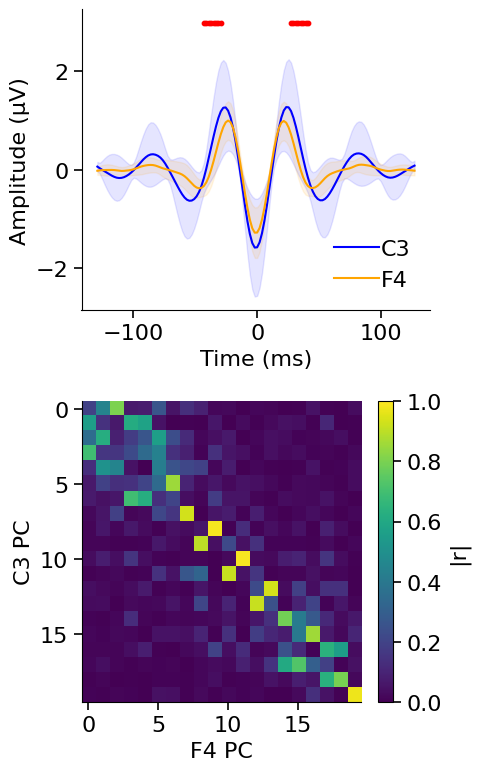

In [8]:
fig_b, axes_b = plt.subplots(2, 1, figsize=(5, 8))

unique_subjects = np.unique(all_bursts['subject'])
mean_waveforms_C3 = []
mean_waveforms_F4 = []
subjects_used = []

for subject in unique_subjects:
    mask_c3 = c3_idx & (all_bursts['subject'] == subject)
    mask_f4 = f4_idx & (all_bursts['subject'] == subject)
    w_c3 = all_bursts['waveform'][mask_c3] * 1e3
    w_f4 = all_bursts['waveform'][mask_f4] * 1e3
    if len(w_c3) > 0 and len(w_f4) > 0:
        mean_waveforms_C3.append(np.mean(w_c3, axis=0))
        mean_waveforms_F4.append(np.mean(w_f4, axis=0))
        subjects_used.append(subject)

matrix_mean_waveforms_C3 = np.array(mean_waveforms_C3)
matrix_mean_waveforms_F4 = np.array(mean_waveforms_F4)
print(f"Subjects with both C3 and F4: {len(subjects_used)}")

T_obs, clusters, cluster_p_values, H0 = permutation_cluster_1samp_test(
    matrix_mean_waveforms_C3 - matrix_mean_waveforms_F4, n_permutations=1000
)

times_ms = all_bursts['waveform_times'] * 1e3
ax = axes_b[0]
ax.plot(times_ms, np.mean(matrix_mean_waveforms_C3, axis=0), label="C3", color="blue")
ax.plot(times_ms, np.mean(matrix_mean_waveforms_F4, axis=0), label="F4", color="orange")
ax.fill_between(
    times_ms,
    np.mean(matrix_mean_waveforms_C3, axis=0) - np.std(matrix_mean_waveforms_C3, axis=0),
    np.mean(matrix_mean_waveforms_C3, axis=0) + np.std(matrix_mean_waveforms_C3, axis=0),
    color="blue", alpha=0.1,
)
ax.fill_between(
    times_ms,
    np.mean(matrix_mean_waveforms_F4, axis=0) - np.std(matrix_mean_waveforms_F4, axis=0),
    np.mean(matrix_mean_waveforms_F4, axis=0) + np.std(matrix_mean_waveforms_F4, axis=0),
    color="orange", alpha=0.1,
)
sig_y = np.max(np.abs(np.concatenate([matrix_mean_waveforms_C3, matrix_mean_waveforms_F4]))) * 0.8
for i_c, c in enumerate(clusters):
    if cluster_p_values[i_c] < 0.05:
        ax.scatter(times_ms[c[0]], [sig_y] * len(c[0]), color='red', s=10, zorder=5)
ax.set_xlabel("Time (ms)")
ax.set_ylabel("Amplitude (µV)")
ax.legend(loc='lower right')

min_pcs = min(model_laplac_C3.components_.shape[0], model_laplac_F4.components_.shape[0])
comp_corrmat_C3_F4 = np.zeros((min_pcs, min_pcs))
for i in range(min_pcs):
    for j in range(min_pcs):
        comp_corrmat_C3_F4[i, j] = np.abs(
            spearmanr(model_laplac_C3.components_[i, :], model_laplac_F4.components_[j, :])[0]
        )

ax = axes_b[1]
im = ax.imshow(comp_corrmat_C3_F4, aspect='auto', origin='upper', cmap='viridis', vmin=0, vmax=1)
plt.colorbar(im, ax=ax, label='|r|')
ax.set_xlabel('F4 PC')
ax.set_ylabel('C3 PC')

plt.tight_layout()
plt.savefig(f'/home/qmoreau/schmidt_data/figures/figure_03_waveform_pca.pdf', bbox_inches='tight')
plt.show()